In [11]:
# Travail du membre 1(Rihabe)
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

In [12]:
# Création d'une session Spark
# SparkSession est le point d’entrée principal pour utiliser PySpark.
# Elle permet de travailler avec les DataFrames, SQL, fichiers, etc.
spark = SparkSession.builder \
    .appName("projetBigData") \
    .getOrCreate()

In [13]:
from google.colab import files
uploaded = files.upload()

Saving cardio_train.csv to cardio_train (1).csv


In [14]:
# ===== HDFS SETUP COMPLET (en 1 cellule) =====

import os
import shutil
import datetime
from google.colab import drive

# Monter Drive
try:
    drive.mount('/content/drive', force_remount=False)
except:
    pass


class HDFSSimulator:
    HDFS_ROOT = "/content/drive/MyDrive/hdfs_root"

    @classmethod
    def init(cls):
        os.makedirs(cls.HDFS_ROOT, exist_ok=True)
        print(f"HDFS NameNode initialized at: {cls.HDFS_ROOT}")
        print("HDFS Cluster Status: ACTIVE")

    @classmethod
    def _real_path(cls, hdfs_path):
        if hdfs_path.startswith("/"):
            return cls.HDFS_ROOT + hdfs_path
        return os.path.join(cls.HDFS_ROOT, hdfs_path)

    @classmethod
    def mkdir(cls, path):
        os.makedirs(cls._real_path(path), exist_ok=True)
        print(f"$ hdfs dfs -mkdir -p {path}")

    @classmethod
    def ls(cls, path="/"):
        real_path = cls._real_path(path)
        print(f"$ hdfs dfs -ls {path}")
        if not os.path.exists(real_path):
            print(f"ls: `{path}': No such file or directory")
            return
        items = sorted(os.listdir(real_path))
        print(f"Found {len(items)} items")
        for item in items:
            full = os.path.join(real_path, item)
            is_file = os.path.isfile(full)
            size = os.path.getsize(full) if is_file else 0
            mtime = datetime.datetime.fromtimestamp(os.path.getmtime(full))
            perm = "-rw-r--r--" if is_file else "drwxr-xr-x"
            print(f"{perm}   1 hadoop supergroup {size:>12} {mtime.strftime('%Y-%m-%d %H:%M')} {path.rstrip('/')}/{item}")

    @classmethod
    def put(cls, local_path, hdfs_path):
        real_path = cls._real_path(hdfs_path)
        if os.path.isdir(real_path):
            real_path = os.path.join(real_path, os.path.basename(local_path))
        os.makedirs(os.path.dirname(real_path), exist_ok=True)
        shutil.copy(local_path, real_path)
        size = os.path.getsize(real_path)
        print(f"$ hdfs dfs -put {local_path} {hdfs_path}")
        print(f"Uploaded {size:,} bytes to HDFS")

    @classmethod
    def cat(cls, path, n=5):
        real_path = cls._real_path(path)
        print(f"$ hdfs dfs -cat {path} | head -{n}")
        with open(real_path, "r") as f:
            for i, line in enumerate(f):
                if i >= n: break
                print(line.rstrip())


# Initialiser et créer la structure
hdfs = HDFSSimulator
hdfs.init()
print()

hdfs.mkdir("/projet/cardio/raw")
hdfs.mkdir("/projet/cardio/processed")
hdfs.mkdir("/projet/cardio/models")
print()

# Mettre le CSV dans HDFS
hdfs.put("/content/cardio_train.csv", "/projet/cardio/raw/cardio_train.csv")
print()

# Vérification
hdfs.ls("/projet/cardio/raw")
print()
hdfs.cat("/projet/cardio/raw/cardio_train.csv", n=3)

Mounted at /content/drive
HDFS NameNode initialized at: /content/drive/MyDrive/hdfs_root
HDFS Cluster Status: ACTIVE

$ hdfs dfs -mkdir -p /projet/cardio/raw
$ hdfs dfs -mkdir -p /projet/cardio/processed
$ hdfs dfs -mkdir -p /projet/cardio/models

$ hdfs dfs -put /content/cardio_train.csv /projet/cardio/raw/cardio_train.csv
Uploaded 2,941,524 bytes to HDFS

$ hdfs dfs -ls /projet/cardio/raw
Found 1 items
-rw-r--r--   1 hadoop supergroup      2941524 2026-06-05 00:13 /projet/cardio/raw/cardio_train.csv

$ hdfs dfs -cat /projet/cardio/raw/cardio_train.csv | head -3
id;age;gender;height;weight;ap_hi;ap_lo;cholesterol;gluc;smoke;alco;active;cardio
0;18393;2;168;62.0;110;80;1;1;0;0;1;0
1;20228;1;156;85.0;140;90;3;1;0;0;1;1


In [15]:
real_path = hdfs._real_path("/projet/cardio/raw/cardio_train.csv")

df = spark.read.csv(
    real_path,
    header=True,
    inferSchema=True,
    sep=";"
)

print("Données chargées depuis HDFS")
print("Nombre de lignes :", df.count())
df.show(3)

Données chargées depuis HDFS
Nombre de lignes : 70000
+---+-----+------+------+------+-----+-----+-----------+----+-----+----+------+------+
| id|  age|gender|height|weight|ap_hi|ap_lo|cholesterol|gluc|smoke|alco|active|cardio|
+---+-----+------+------+------+-----+-----+-----------+----+-----+----+------+------+
|  0|18393|     2|   168|  62.0|  110|   80|          1|   1|    0|   0|     1|     0|
|  1|20228|     1|   156|  85.0|  140|   90|          3|   1|    0|   0|     1|     1|
|  2|18857|     1|   165|  64.0|  130|   70|          3|   1|    0|   0|     0|     1|
+---+-----+------+------+------+-----+-----+-----------+----+-----+----+------+------+
only showing top 3 rows


In [16]:
# Affiche la structure du DataFrame
df.printSchema()

root
 |-- id: integer (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: integer (nullable = true)
 |-- height: integer (nullable = true)
 |-- weight: double (nullable = true)
 |-- ap_hi: integer (nullable = true)
 |-- ap_lo: integer (nullable = true)
 |-- cholesterol: integer (nullable = true)
 |-- gluc: integer (nullable = true)
 |-- smoke: integer (nullable = true)
 |-- alco: integer (nullable = true)
 |-- active: integer (nullable = true)
 |-- cardio: integer (nullable = true)



In [17]:
# Affiche le nombre total de lignes dans le DataFrame
print("Nombre de lignes :", df.count())

Nombre de lignes : 70000


In [18]:
df.describe().show()

+-------+------------------+------------------+-------------------+------------------+------------------+-----------------+------------------+------------------+------------------+-------------------+--------------------+------------------+------------------+
|summary|                id|               age|             gender|            height|            weight|            ap_hi|             ap_lo|       cholesterol|              gluc|              smoke|                alco|            active|            cardio|
+-------+------------------+------------------+-------------------+------------------+------------------+-----------------+------------------+------------------+------------------+-------------------+--------------------+------------------+------------------+
|  count|             70000|             70000|              70000|             70000|             70000|            70000|             70000|             70000|             70000|              70000|               70000

In [19]:
# Affiche la première ligne du DataFrame
df.head()

Row(id=0, age=18393, gender=2, height=168, weight=62.0, ap_hi=110, ap_lo=80, cholesterol=1, gluc=1, smoke=0, alco=0, active=1, cardio=0)

In [20]:
# Compte les valeurs manquantes (NULL) dans chaque colonne
from pyspark.sql.functions import col, when, count

df.select([
    # Pour chaque colonne du DataFrame
    count(
        # Vérifie si la valeur est NULL
        when(col(c).isNull(), c)
    ).alias(c) # Nom de la colonne dans le résultat
    for c in df.columns
]).show()

+---+---+------+------+------+-----+-----+-----------+----+-----+----+------+------+
| id|age|gender|height|weight|ap_hi|ap_lo|cholesterol|gluc|smoke|alco|active|cardio|
+---+---+------+------+------+-----+-----+-----------+----+-----+----+------+------+
|  0|  0|     0|     0|     0|    0|    0|          0|   0|    0|   0|     0|     0|
+---+---+------+------+------+-----+-----+-----------+----+-----+----+------+------+



In [21]:
# Calcule le nombre de doublons dans le DataFrame
# Nombre total de lignes - nombre de lignes sans doublons
duplicates = df.count() - df.dropDuplicates().count()
print("Nombre de doublons :", duplicates)

Nombre de doublons : 0


In [22]:
import pandas as pd
import time

df_pandas = pd.read_csv('/content/cardio_train.csv', sep=';')  # ← ajouter sep=';'

In [23]:
import pandas as pd
import time

# On charge le CSV avec pandas (plus simple que PySpark pour cette simulation)
df_pandas = pd.read_csv('/content/cardio_train.csv')

# === PRODUCER : envoie les lignes du CSV dans un "topic" ===
kafka_topic = []  # Notre topic Kafka simulé (une simple liste Python)

print("===PRODUCER démarre ===\n")
for index, row in df_pandas.iterrows():
    message = row.to_dict()  # Convertit la ligne en dictionnaire
    kafka_topic.append(message)  # Envoie dans le topic

    # Afficher les 3 premiers messages pour vérifier
    if index < 3:
        print(f"Message {index + 1} envoyé : {message}")

    time.sleep(0.0005)  # Petit délai pour simuler le temps réel

print(f"\nProducer a envoyé {len(kafka_topic)} messages dans le topic")

===PRODUCER démarre ===

Message 1 envoyé : {'id;age;gender;height;weight;ap_hi;ap_lo;cholesterol;gluc;smoke;alco;active;cardio': '0;18393;2;168;62.0;110;80;1;1;0;0;1;0'}
Message 2 envoyé : {'id;age;gender;height;weight;ap_hi;ap_lo;cholesterol;gluc;smoke;alco;active;cardio': '1;20228;1;156;85.0;140;90;3;1;0;0;1;1'}
Message 3 envoyé : {'id;age;gender;height;weight;ap_hi;ap_lo;cholesterol;gluc;smoke;alco;active;cardio': '2;18857;1;165;64.0;130;70;3;1;0;0;0;1'}

Producer a envoyé 70000 messages dans le topic


In [24]:
from google.colab import drive

# Monter Google Drive — un popup demande de se connecter à son compte Google
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
# Sauvegarder le dataset au format CSV sur Drive
chemin_sortie = '/content/drive/MyDrive/heart_explored.csv'

df.toPandas().to_csv(chemin_sortie, index=False)

print(f"Fichier sauvegardé sur Google Drive")
print(f"Chemin : {chemin_sortie}")
print(f"Contenu : {df.count()} lignes × {len(df.columns)} colonnes")
print()

Fichier sauvegardé sur Google Drive
Chemin : /content/drive/MyDrive/heart_explored.csv
Contenu : 70000 lignes × 13 colonnes



In [26]:
# Travail du membre 2 (Maryem)
# Afficher les colonnes du dataset
print(df.columns)

# Afficher les 5 premières lignes
df.show(5)

['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']
+---+-----+------+------+------+-----+-----+-----------+----+-----+----+------+------+
| id|  age|gender|height|weight|ap_hi|ap_lo|cholesterol|gluc|smoke|alco|active|cardio|
+---+-----+------+------+------+-----+-----+-----------+----+-----+----+------+------+
|  0|18393|     2|   168|  62.0|  110|   80|          1|   1|    0|   0|     1|     0|
|  1|20228|     1|   156|  85.0|  140|   90|          3|   1|    0|   0|     1|     1|
|  2|18857|     1|   165|  64.0|  130|   70|          3|   1|    0|   0|     0|     1|
|  3|17623|     2|   169|  82.0|  150|  100|          1|   1|    0|   0|     1|     1|
|  4|17474|     1|   156|  56.0|  100|   60|          1|   1|    0|   0|     0|     0|
+---+-----+------+------+------+-----+-----+-----------+----+-----+----+------+------+
only showing top 5 rows


In [27]:
from pyspark.sql.functions import col, round

# Convertir la taille de cm vers mètre
# Exemple : 170 cm → 1.70 m
df = df.withColumn(
    "height_m",
    col("height") / 100
)

# Calcul du BMI Body Mass Index (IMC)
# Formule :
# BMI = poids / (taille²)
# round(...,2) → garder seulement 2 chiffres après la virgule
df = df.withColumn(
    "bmi",
    round(
        col("weight") /
        (col("height_m") ** 2),
        2
    )
)

# Afficher quelques résultats pour vérifier
df.select(
    "height",
    "weight",
    "height_m",
    "bmi"
).show(5)

+------+------+--------+-----+
|height|weight|height_m|  bmi|
+------+------+--------+-----+
|   168|  62.0|    1.68|21.97|
|   156|  85.0|    1.56|34.93|
|   165|  64.0|    1.65|23.51|
|   169|  82.0|    1.69|28.71|
|   156|  56.0|    1.56|23.01|
+------+------+--------+-----+
only showing top 5 rows


In [28]:
# Convertir l'âge de jours → années
# On divise par 365
df = df.withColumn(
    "age_years",
    round(
        col("age") / 365,
        1
    )
)

# Vérifier le résultat
df.select(
    "age",
    "age_years"
).show(5)

+-----+---------+
|  age|age_years|
+-----+---------+
|18393|     50.4|
|20228|     55.4|
|18857|     51.7|
|17623|     48.3|
|17474|     47.9|
+-----+---------+
only showing top 5 rows


In [29]:
# Créer une nouvelle feature :
# ratio cholesterol / age

df = df.withColumn(
    "chol_age_ratio",
    round(
        col("cholesterol") /
        col("age_years"),
        3
    )
)

# Vérification
df.select(
    "cholesterol",
    "age_years",
    "chol_age_ratio"
).show(5)

+-----------+---------+--------------+
|cholesterol|age_years|chol_age_ratio|
+-----------+---------+--------------+
|          1|     50.4|          0.02|
|          3|     55.4|         0.054|
|          3|     51.7|         0.058|
|          1|     48.3|         0.021|
|          1|     47.9|         0.021|
+-----------+---------+--------------+
only showing top 5 rows


In [30]:
# Afficher les nouvelles features créées
df.select(
    "age",
    "age_years",
    "height",
    "weight",
    "height_m",
    "bmi",
    "cholesterol",
    "chol_age_ratio"
).show(5)

+-----+---------+------+------+--------+-----+-----------+--------------+
|  age|age_years|height|weight|height_m|  bmi|cholesterol|chol_age_ratio|
+-----+---------+------+------+--------+-----+-----------+--------------+
|18393|     50.4|   168|  62.0|    1.68|21.97|          1|          0.02|
|20228|     55.4|   156|  85.0|    1.56|34.93|          3|         0.054|
|18857|     51.7|   165|  64.0|    1.65|23.51|          3|         0.058|
|17623|     48.3|   169|  82.0|    1.69|28.71|          1|         0.021|
|17474|     47.9|   156|  56.0|    1.56|23.01|          1|         0.021|
+-----+---------+------+------+--------+-----+-----------+--------------+
only showing top 5 rows


In [31]:
# Colonnes à utiliser pour le Machine Learning

feature_columns = [

    # Variables médicales originales
    "age_years",
    "height",
    "weight",
    "ap_hi",
    "ap_lo",

    # Features créées
    "bmi",
    "chol_age_ratio",

    # Variables catégorielles déjà numériques
    "gender",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active"
]

In [32]:
# Importer VectorAssembler
# Sert à regrouper plusieurs colonnes
# en une seule colonne "features"

from pyspark.ml.feature import VectorAssembler


# Créer le VectorAssembler
assembler = VectorAssembler(

    # Colonnes d'entrée
    inputCols=feature_columns,

    # Nom de la nouvelle colonne créée
    outputCol="features"
)


# Appliquer la transformation sur le DataFrame
df = assembler.transform(df)

In [33]:
# Afficher la colonne features

df.select(
    "features"
).show(5, truncate=False)

+-----------------------------------------------------------------+
|features                                                         |
+-----------------------------------------------------------------+
|[50.4,168.0,62.0,110.0,80.0,21.97,0.02,2.0,1.0,1.0,0.0,0.0,1.0]  |
|[55.4,156.0,85.0,140.0,90.0,34.93,0.054,1.0,3.0,1.0,0.0,0.0,1.0] |
|[51.7,165.0,64.0,130.0,70.0,23.51,0.058,1.0,3.0,1.0,0.0,0.0,0.0] |
|[48.3,169.0,82.0,150.0,100.0,28.71,0.021,2.0,1.0,1.0,0.0,0.0,1.0]|
|[47.9,156.0,56.0,100.0,60.0,23.01,0.021,1.0,1.0,1.0,0.0,0.0,0.0] |
+-----------------------------------------------------------------+
only showing top 5 rows


In [34]:
# Importer StandardScaler
# Sert à normaliser les données

from pyspark.ml.feature import StandardScaler


# Créer le scaler
scaler = StandardScaler(

    # Colonne d'entrée
    inputCol="features",

    # Nouvelle colonne créée
    outputCol="scaled_features",

    # Centrer les données autour de 0
    withMean=True,

    # Standardiser (écart-type = 1)
    withStd=True
)


# Entraîner le scaler sur les données
scaler_model = scaler.fit(df)

# Appliquer la transformation
df = scaler_model.transform(df)

In [35]:
# Afficher les features normalisées

df.select(
    "features",
    "scaled_features"
).show(5, truncate=False)

+-----------------------------------------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|features                                                         |scaled_features                                                                                                                                                                                                                                                          |
+-----------------------------------------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [36]:
# Supprimer les anciennes colonnes
# pour éviter les conflits Spark

df = df.drop("features")

df = df.drop("scaled_features")

In [37]:
# Importer les outils nécessaires

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StandardScaler
from pyspark.ml import Pipeline


# Colonnes utilisées pour le Machine Learning
feature_columns = [

    "age_years",
    "height",
    "weight",
    "ap_hi",
    "ap_lo",

    "bmi",
    "chol_age_ratio",

    "gender",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active"
]


# Étape 1 : assembler les colonnes
assembler = VectorAssembler(

    inputCols=feature_columns,

    outputCol="features"
)


# Étape 2 : normalisation
scaler = StandardScaler(

    inputCol="features",

    outputCol="scaled_features",

    withMean=True,

    withStd=True
)


# Créer le pipeline
pipeline = Pipeline(

    stages=[

        assembler,

        scaler
    ]
)


# Entraîner le pipeline
pipeline_model = pipeline.fit(df)

# Transformer les données
df_pipeline = pipeline_model.transform(df)

In [38]:
df_pipeline.select(
    "features",
    "scaled_features"
).show(5, truncate=False)

+-----------------------------------------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|features                                                         |scaled_features                                                                                                                                                                                                                                                          |
+-----------------------------------------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [39]:
# Diviser les données en :
# 80% entraînement
# 20% test

train_data, test_data = df_pipeline.randomSplit(

    # proportions
    [0.8, 0.2],

    # seed pour obtenir les mêmes résultats
    seed=42
)

In [40]:
# Afficher le nombre de lignes

print("Nombre train :", train_data.count())

print("Nombre test :", test_data.count())

Nombre train : 55851
Nombre test : 14149


In [41]:
# Vérifier les colonnes finales

print(df_pipeline.columns)

['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'height_m', 'bmi', 'age_years', 'chol_age_ratio', 'features', 'scaled_features']


In [42]:
# Afficher un aperçu des données finales

df_pipeline.select(

    "cardio",            # target
    "features",
    "scaled_features"

).show(5, truncate=False)

+------+-----------------------------------------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|cardio|features                                                         |scaled_features                                                                                                                                                                                                                                                          |
+------+-----------------------------------------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [43]:
# Créer une copie sans les colonnes Spark ML

train_save = train_data.drop(

    "features",
    "scaled_features"
)

test_save = test_data.drop(

    "features",
    "scaled_features"
)

In [44]:
# Vérifier les colonnes

print(train_save.columns)

['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'height_m', 'bmi', 'age_years', 'chol_age_ratio']


In [45]:
# Sauvegarder train dataset

train_save.write.mode(

    "overwrite"

).csv(

    "/content/train_data",

    header=True
)

In [46]:
# Sauvegarder test dataset

test_save.write.mode(

    "overwrite"

).csv(

    "/content/test_data",

    header=True
)

In [47]:
# Voir les dossiers créés

import os

print(os.listdir("/content"))

['.config', 'train_data', 'cardio_train (1).csv', 'exploration_cardio.ipynb', 'test_data', 'cardio_train.csv', 'drive', 'sample_data']


In [48]:
# ===== Rapport qualité des données =====

print("===== RAPPORT FINAL MEMBRE 2 =====")

# Nombre total lignes
print("Nombre total lignes :", df.count())

# Nombre colonnes
print("Nombre colonnes :", len(df.columns))

# Taille train/test
print("Train dataset :", train_data.count())

print("Test dataset :", test_data.count())

# Vérifier doublons
duplicates = df.count() - df.dropDuplicates().count()

print("Doublons restants :", duplicates)

print("Prétraitement terminé avec succès")

===== RAPPORT FINAL MEMBRE 2 =====
Nombre total lignes : 70000
Nombre colonnes : 17
Train dataset : 55851
Test dataset : 14149
Doublons restants : 0
Prétraitement terminé avec succès


In [49]:
# Travail du membre 3
# Voir combien de personnes malades/non malades

train_data.groupBy(
    "cardio"
).count().show()

+------+-----+
|cardio|count|
+------+-----+
|     1|27889|
|     0|27962|
+------+-----+



In [50]:
# Corrélation entre âge et maladie cardiaque

corr_age = train_data.stat.corr(

    "age_years",
    "cardio"
)

print("Corrélation âge-cardio :", corr_age)


# Corrélation BMI et maladie cardiaque
corr_bmi = train_data.stat.corr(

    "bmi",
    "cardio"
)

print("Corrélation bmi-cardio :", corr_bmi)


# Corrélation pression sanguine haute
corr_pressure = train_data.stat.corr(

    "ap_hi",
    "cardio"
)

print("Corrélation ap_hi-cardio :", corr_pressure)

Corrélation âge-cardio : 0.23528334248443927
Corrélation bmi-cardio : 0.16628446238989347
Corrélation ap_hi-cardio : 0.05313065631783512


In [51]:
# Importer les modèles Machine Learning

from pyspark.ml.classification import (

    LogisticRegression,

    RandomForestClassifier,

    GBTClassifier,

    DecisionTreeClassifier
)

In [52]:
# Régression Logistique

lr = LogisticRegression(

    # Variable cible
    labelCol="cardio",

    # Features du membre 2
    featuresCol="scaled_features"
)

In [53]:
# Entraîner le modèle

lr_model = lr.fit(train_data)

In [54]:
# Faire les prédictions sur test_data

lr_predictions = lr_model.transform(
    test_data
)

In [55]:
# Voir les prédictions

lr_predictions.select(

    "cardio",

    "prediction",

    "probability"

).show(10, truncate=False)

+------+----------+----------------------------------------+
|cardio|prediction|probability                             |
+------+----------+----------------------------------------+
|1     |1.0       |[0.26897958852831755,0.7310204114716825]|
|0     |1.0       |[0.16682965642875153,0.8331703435712485]|
|0     |0.0       |[0.7522592023523652,0.2477407976476348] |
|0     |0.0       |[0.665790857357229,0.334209142642771]   |
|0     |0.0       |[0.6091100181039885,0.39088998189601154]|
|0     |0.0       |[0.6271212053805402,0.37287879461945983]|
|0     |1.0       |[0.47490999425453867,0.5250900057454613]|
|0     |0.0       |[0.6422203055344059,0.3577796944655941] |
|1     |0.0       |[0.5391823097497096,0.4608176902502904] |
|1     |1.0       |[0.16434059632488382,0.8356594036751162]|
+------+----------+----------------------------------------+
only showing top 10 rows


In [56]:
# Importer les évaluateurs

from pyspark.ml.evaluation import (

    MulticlassClassificationEvaluator,

    BinaryClassificationEvaluator
)

In [57]:
# Accuracy = % bonnes prédictions

accuracy_evaluator = MulticlassClassificationEvaluator(

    labelCol="cardio",

    predictionCol="prediction",

    metricName="accuracy"
)

accuracy = accuracy_evaluator.evaluate(
    lr_predictions
)

print("Accuracy :", accuracy)

Accuracy : 0.7193441232595943


In [58]:
# F1 Score

f1_evaluator = MulticlassClassificationEvaluator(

    labelCol="cardio",

    predictionCol="prediction",

    metricName="f1"
)

f1 = f1_evaluator.evaluate(
    lr_predictions
)

print("F1 Score :", f1)

F1 Score : 0.718980092043953


In [59]:
# Precision

precision_evaluator = MulticlassClassificationEvaluator(

    labelCol="cardio",

    predictionCol="prediction",

    metricName="weightedPrecision"
)

precision = precision_evaluator.evaluate(
    lr_predictions
)

print("Precision :", precision)

Precision : 0.7206042532396221


In [60]:
# Recall

recall_evaluator = MulticlassClassificationEvaluator(

    labelCol="cardio",

    predictionCol="prediction",

    metricName="weightedRecall"
)

recall = recall_evaluator.evaluate(
    lr_predictions
)

print("Recall :", recall)

Recall : 0.7193441232595943


In [61]:
# AUC ROC

auc_evaluator = BinaryClassificationEvaluator(

    labelCol="cardio",

    rawPredictionCol="rawPrediction",

    metricName="areaUnderROC"
)

auc = auc_evaluator.evaluate(
    lr_predictions
)

print("AUC ROC :", auc)

AUC ROC : 0.7837025765705175


In [62]:
print("===== Logistic Regression =====")

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 Score :", f1)

print("AUC ROC :", auc)

===== Logistic Regression =====
Accuracy : 0.7193441232595943
Precision : 0.7206042532396221
Recall : 0.7193441232595943
F1 Score : 0.718980092043953
AUC ROC : 0.7837025765705175


In [63]:
# Réimporter les classes (au cas où le kernel a été redémarré)
from pyspark.ml.classification import (
    LogisticRegression,
    RandomForestClassifier,
    GBTClassifier,
    DecisionTreeClassifier
)

from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator,
    BinaryClassificationEvaluator
)

print("Imports OK ✅")

Imports OK ✅


In [64]:
# Random Forest avec 100 arbres (douaa)

rf = RandomForestClassifier(

    # Variable cible
    labelCol="cardio",

    # Features normalisées du Membre 2
    featuresCol="scaled_features",

    # Nombre d'arbres dans la forêt
    numTrees=100,

    # Pour avoir toujours les mêmes résultats
    seed=42
)


# Entraîner le modèle
rf_model = rf.fit(train_data)

# Faire les prédictions
rf_predictions = rf_model.transform(test_data)


In [65]:
# Évaluer Random Forest avec les 5 métriques

rf_accuracy = accuracy_evaluator.evaluate(rf_predictions)

rf_precision = precision_evaluator.evaluate(rf_predictions)

rf_recall = recall_evaluator.evaluate(rf_predictions)

rf_f1 = f1_evaluator.evaluate(rf_predictions)

rf_auc = auc_evaluator.evaluate(rf_predictions)


# Afficher les résultats
print("===== Random Forest =====")

print("Accuracy :", rf_accuracy)

print("Precision :", rf_precision)

print("Recall :", rf_recall)

print("F1 Score :", rf_f1)

print("AUC ROC :", rf_auc)


===== Random Forest =====
Accuracy : 0.7247862039720122
Precision : 0.7284593992404201
Recall : 0.7247862039720121
F1 Score : 0.7237361570322263
AUC ROC : 0.7953199019107738


In [66]:
# Importance des features avec Random Forest

# rf_model.featureImportances donne un score à chaque feature
import pandas as pd

# Liste des noms de colonnes (même ordre que feature_columns du Membre 2)
feature_names = [
    "age_years", "height", "weight", "ap_hi", "ap_lo",
    "bmi", "chol_age_ratio",
    "gender", "cholesterol", "gluc", "smoke", "alco", "active"
]


# Récupérer les scores d'importance
importances = rf_model.featureImportances.toArray()


# Créer un DataFrame pandas pour afficher proprement
df_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)


print("===== Importance des features =====")
print(df_importance.to_string(index=False))


===== Importance des features =====
       Feature  Importance
         ap_hi    0.531806
         ap_lo    0.226542
chol_age_ratio    0.072194
     age_years    0.071901
   cholesterol    0.066438
           bmi    0.015767
        weight    0.009703
          gluc    0.004092
        active    0.000549
        height    0.000498
         smoke    0.000240
          alco    0.000180
        gender    0.000090


In [67]:
# Gradient Boosted Trees

gbt = GBTClassifier(

    # Variable cible
    labelCol="cardio",

    # Features normalisées du Membre 2
    featuresCol="scaled_features",

    # Nombre d'itérations
    maxIter=50,

    # Reproductibilité
    seed=42
)


# Entraîner le modèle
gbt_model = gbt.fit(train_data)

# Faire les prédictions
gbt_predictions = gbt_model.transform(test_data)


In [68]:
# Évaluer GBT

gbt_accuracy = accuracy_evaluator.evaluate(gbt_predictions)

gbt_precision = precision_evaluator.evaluate(gbt_predictions)

gbt_recall = recall_evaluator.evaluate(gbt_predictions)

gbt_f1 = f1_evaluator.evaluate(gbt_predictions)

gbt_auc = auc_evaluator.evaluate(gbt_predictions)


# Afficher les résultats
print("===== Gradient Boosted Trees =====")

print("Accuracy :", gbt_accuracy)

print("Precision :", gbt_precision)

print("Recall :", gbt_recall)

print("F1 Score :", gbt_f1)

print("AUC ROC :", gbt_auc)


===== Gradient Boosted Trees =====
Accuracy : 0.7333380450915259
Precision : 0.7366384055431134
Recall : 0.7333380450915259
F1 Score : 0.7324584052988252
AUC ROC : 0.8021120793089708


In [69]:
# Decision Tree

dt = DecisionTreeClassifier(

    # Variable cible
    labelCol="cardio",

    # Features normalisées
    featuresCol="scaled_features",

    # Profondeur maximale de l'arbre
    maxDepth=5,

    # Reproductibilité
    seed=42
)


# Entraîner
dt_model = dt.fit(train_data)

# Prédictions
dt_predictions = dt_model.transform(test_data)


In [70]:
# Évaluer Decision Tree

dt_accuracy = accuracy_evaluator.evaluate(dt_predictions)

dt_precision = precision_evaluator.evaluate(dt_predictions)

dt_recall = recall_evaluator.evaluate(dt_predictions)

dt_f1 = f1_evaluator.evaluate(dt_predictions)

dt_auc = auc_evaluator.evaluate(dt_predictions)


# Afficher les résultats
print("===== Decision Tree =====")

print("Accuracy :", dt_accuracy)

print("Precision :", dt_precision)

print("Recall :", dt_recall)

print("F1 Score :", dt_f1)

print("AUC ROC :", dt_auc)


===== Decision Tree =====
Accuracy : 0.7290267863453248
Precision : 0.7388135145843022
Recall : 0.7290267863453248
F1 Score : 0.7263155582735945
AUC ROC : 0.5921347294244299


In [71]:
# Création du tableau comparatif avec pandas

import pandas as pd


# Construire le DataFrame de comparaison
results = pd.DataFrame({

    "Modèle": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosted Trees",
        "Decision Tree"
    ],

    "Accuracy":  [accuracy,  rf_accuracy,  gbt_accuracy,  dt_accuracy],
    "Precision": [precision, rf_precision, gbt_precision, dt_precision],
    "Recall":    [recall,    rf_recall,    gbt_recall,    dt_recall],
    "F1 Score":  [f1,        rf_f1,        gbt_f1,        dt_f1],
    "AUC ROC":   [auc,       rf_auc,       gbt_auc,       dt_auc]
})


# Arrondir à 4 décimales pour lisibilité
results_rounded = results.round(4)


print("===== COMPARAISON DES 4 MODÈLES =====\n")
print(results_rounded.to_string(index=False))


===== COMPARAISON DES 4 MODÈLES =====

                Modèle  Accuracy  Precision  Recall  F1 Score  AUC ROC
   Logistic Regression    0.7193     0.7206  0.7193    0.7190   0.7837
         Random Forest    0.7248     0.7285  0.7248    0.7237   0.7953
Gradient Boosted Trees    0.7333     0.7366  0.7333    0.7325   0.8021
         Decision Tree    0.7290     0.7388  0.7290    0.7263   0.5921


In [72]:
# Trouver le meilleur modèle (selon AUC ROC)

best_idx = results["AUC ROC"].idxmax()

best_model_name = results.loc[best_idx, "Modèle"]
best_auc = results.loc[best_idx, "AUC ROC"]


print("===== MEILLEUR MODÈLE =====")
print("Nom :", best_model_name)
print(f"  AUC ROC : {best_auc:.4f}")


# Sélectionner l'objet modèle correspondant
if best_model_name == "Logistic Regression":
    best_model = lr_model
elif best_model_name == "Random Forest":
    best_model = rf_model
elif best_model_name == "Gradient Boosted Trees":
    best_model = gbt_model
else:
    best_model = dt_model


print("\nModèle sélectionné :", type(best_model).__name__)


===== MEILLEUR MODÈLE =====
Nom : Gradient Boosted Trees
  AUC ROC : 0.8021

Modèle sélectionné : GBTClassificationModel


In [73]:
# Sauvegarder le meilleur modèle sur Google Drive

# Le drive devrait déjà être monté (cellule 12 du Membre 1)
# Sinon décommenter la ligne suivante :
# from google.colab import drive
# drive.mount('/content/drive')


chemin_modele = "/content/drive/MyDrive/best_model_cardio"

best_model.write().overwrite().save(chemin_modele)


print("Meilleur modèle sauvegardé !")
print("Chemin :", chemin_modele)
print("Modèle :", best_model_name)


Meilleur modèle sauvegardé !
Chemin : /content/drive/MyDrive/best_model_cardio
Modèle : Gradient Boosted Trees


In [74]:
# Rapport synthétique du travail du Membre 3

print("===== RAPPORT FINAL MEMBRE 3 =====\n")

print("Dataset utilisé :")
print("  - Train :", train_data.count(), "lignes")
print("  - Test  :", test_data.count(), "lignes")

print("\nModèles entraînés : 4")
print("  1. Logistic Regression")
print("  2. Random Forest (100 arbres)")
print("  3. Gradient Boosted Trees (50 iterations)")
print("  4. Decision Tree (profondeur 5)")

print("\nMétriques évaluées : 5")
print("  - Accuracy, Precision, Recall, F1 Score, AUC ROC")

print("\nMeilleur modèle :", best_model_name)
print(f"  AUC ROC : {best_auc:.4f}")

print("\nModèle sauvegardé sur Google Drive")
print("Pour le Membre 4 : utiliser les prédictions et les métriques")
print("pour créer les visualisations (courbe ROC, matrice de confusion, etc.)")


===== RAPPORT FINAL MEMBRE 3 =====

Dataset utilisé :
  - Train : 55851 lignes
  - Test  : 14149 lignes

Modèles entraînés : 4
  1. Logistic Regression
  2. Random Forest (100 arbres)
  3. Gradient Boosted Trees (50 iterations)
  4. Decision Tree (profondeur 5)

Métriques évaluées : 5
  - Accuracy, Precision, Recall, F1 Score, AUC ROC

Meilleur modèle : Gradient Boosted Trees
  AUC ROC : 0.8021

Modèle sauvegardé sur Google Drive
Pour le Membre 4 : utiliser les prédictions et les métriques
pour créer les visualisations (courbe ROC, matrice de confusion, etc.)


In [75]:
# Imports pour les graphiques

import matplotlib.pyplot as plt

import seaborn as sns

import pandas as pd

import numpy as np


# Style des graphiques
sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)

plt.rcParams["font.size"] = 11


print("Bibliothèques importées avec succès")


Bibliothèques importées avec succès


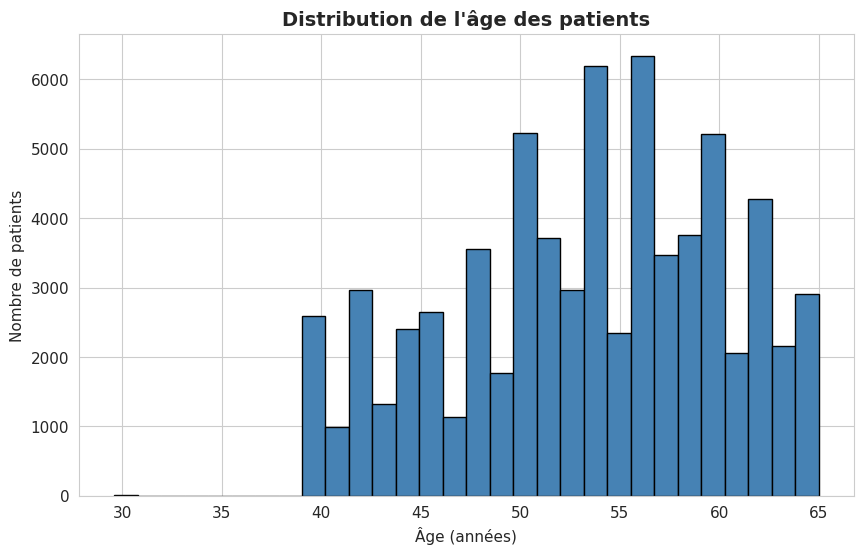

Âge moyen : 53.3 ans
Âge médian : 54.0 ans


In [76]:
# Convertir une partie de df en pandas pour matplotlib

df_pd = df.drop(

    "features",

    "scaled_features"

).toPandas()


# Histogramme de l'âge en années
plt.figure(figsize=(10, 6))

plt.hist(

    df_pd["age_years"],

    bins=30,

    color="steelblue",

    edgecolor="black"
)

plt.title("Distribution de l'âge des patients", fontsize=14, fontweight="bold")

plt.xlabel("Âge (années)")

plt.ylabel("Nombre de patients")

plt.show()


print(f"Âge moyen : {df_pd['age_years'].mean():.1f} ans")

print(f"Âge médian : {df_pd['age_years'].median():.1f} ans")


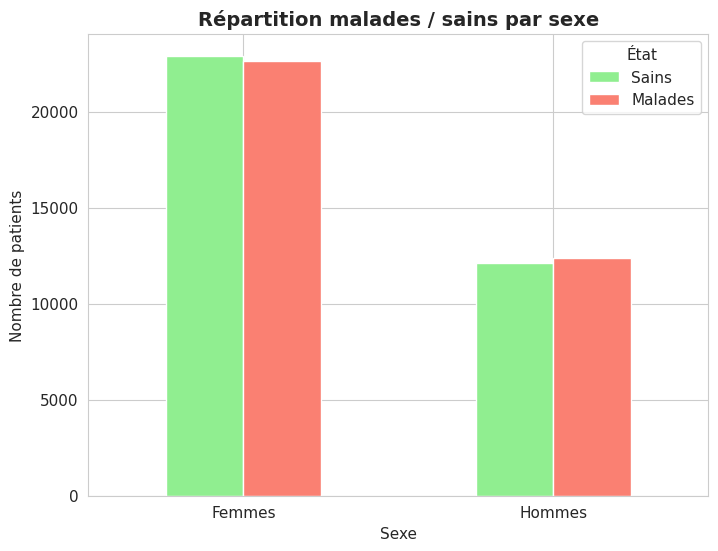


=== Taux de maladie ===
Femmes : 49.7% malades
Hommes : 50.5% malades


In [77]:
# Tableau croisé : sexe × cardio

# 1 = femme, 2 = homme dans ce dataset
crosstab = pd.crosstab(

    df_pd["gender"],

    df_pd["cardio"]
)


# Renommer pour plus de clarté
crosstab.index = ["Femmes", "Hommes"]

crosstab.columns = ["Sains", "Malades"]


# Bar chart
crosstab.plot(

    kind="bar",

    figsize=(8, 6),

    color=["lightgreen", "salmon"]
)

plt.title("Répartition malades / sains par sexe", fontsize=14, fontweight="bold")

plt.xlabel("Sexe")

plt.ylabel("Nombre de patients")

plt.xticks(rotation=0)

plt.legend(title="État")

plt.show()


# Pourcentages
print("\n=== Taux de maladie ===")
for sexe in crosstab.index:
    total = crosstab.loc[sexe].sum()
    malades = crosstab.loc[sexe, "Malades"]
    pct = (malades / total) * 100
    print(f"{sexe} : {pct:.1f}% malades")


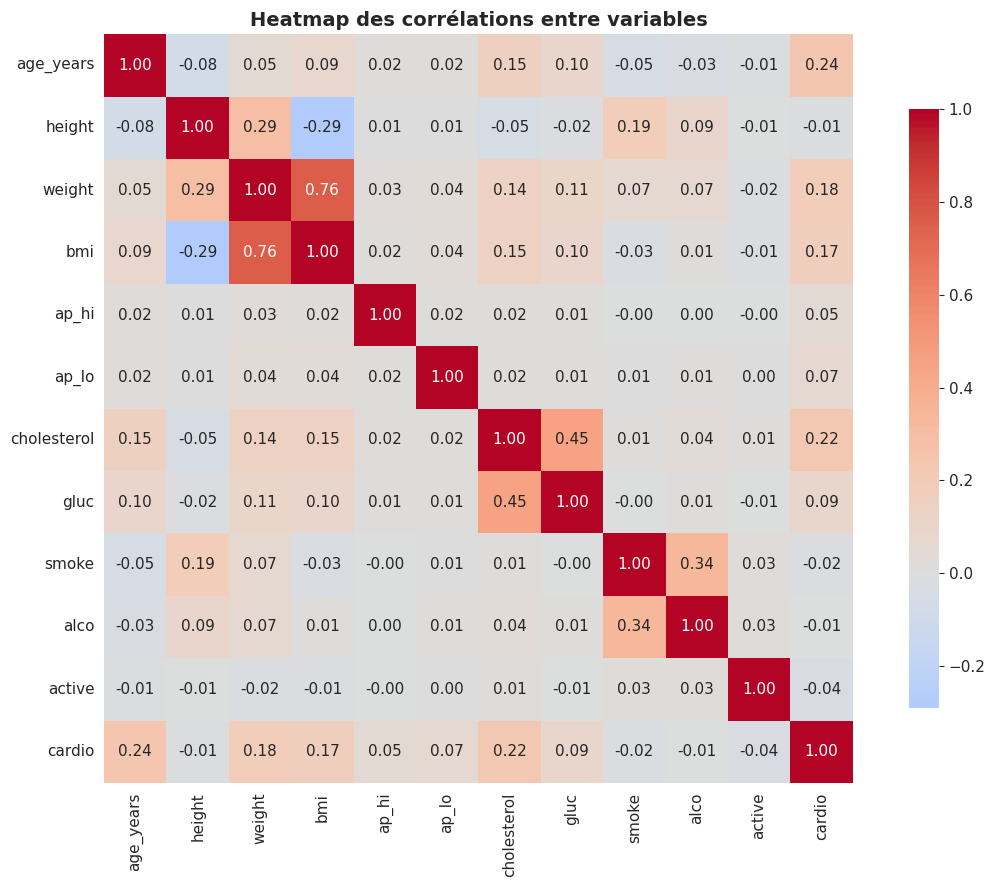


=== Top 5 variables corrélées avec cardio ===
age_years      0.238137
cholesterol    0.221147
weight         0.181660
bmi            0.165633
gluc           0.089307


In [78]:
# On garde les colonnes numériques importantes

cols_corr = [

    "age_years",

    "height",

    "weight",

    "bmi",

    "ap_hi",

    "ap_lo",

    "cholesterol",

    "gluc",

    "smoke",

    "alco",

    "active",

    "cardio"
]


# Matrice de corrélation
corr_matrix = df_pd[cols_corr].corr()


# Heatmap avec seaborn
plt.figure(figsize=(12, 9))

sns.heatmap(

    corr_matrix,

    annot=True,

    fmt=".2f",

    cmap="coolwarm",

    center=0,

    square=True,

    cbar_kws={"shrink": 0.8}
)

plt.title("Heatmap des corrélations entre variables", fontsize=14, fontweight="bold")

plt.tight_layout()

plt.show()


# Top corrélations avec cardio
print("\n=== Top 5 variables corrélées avec cardio ===")

corr_cardio = corr_matrix["cardio"].drop("cardio").abs().sort_values(ascending=False)

print(corr_cardio.head().to_string())


In [79]:
# Créer une vue SQL sur le DataFrame

df.createOrReplaceTempView("cardio_data")


# Vérifier que la vue existe
spark.sql("SHOW TABLES").show()


+---------+-----------+-----------+
|namespace|  tableName|isTemporary|
+---------+-----------+-----------+
|         |cardio_data|       true|
+---------+-----------+-----------+



In [80]:
# Statistiques moyennes par sexe et par état cardio

query1 = '''

SELECT

    gender,

    cardio,

    COUNT(*) as nb_patients,

    AVG(age_years) as age_moyen,

    AVG(bmi) as bmi_moyen,

    AVG(ap_hi) as pression_moyenne

FROM cardio_data

GROUP BY gender, cardio

ORDER BY gender, cardio

'''

spark.sql(query1).show()


+------+------+-----------+------------------+------------------+------------------+
|gender|cardio|nb_patients|         age_moyen|         bmi_moyen|  pression_moyenne|
+------+------+-----------+------------------+------------------+------------------+
|     1|     0|      22914|51.767971545779915|26.891832504146336|119.99231910622326|
|     1|     1|      22616|55.159099752387206|29.097853731871567| 136.3935267067563|
|     2|     0|      12107|  51.6603617741801|25.897897910299722| 121.2658792434129|
|     2|     1|      12363| 54.56786378710691| 27.59328722801893|138.70937474722965|
+------+------+-----------+------------------+------------------+------------------+



In [81]:
# Pourcentage de malades selon le niveau de cholestérol

query2 = '''

SELECT

    cholesterol,

    COUNT(*) as total,

    SUM(cardio) as nb_malades,

    ROUND(SUM(cardio) * 100.0 / COUNT(*), 2) as pourcentage_malades

FROM cardio_data

GROUP BY cholesterol

ORDER BY cholesterol

'''

print("Cholestérol : 1 = normal, 2 = au-dessus, 3 = bien au-dessus\n")

spark.sql(query2).show()


Cholestérol : 1 = normal, 2 = au-dessus, 3 = bien au-dessus

+-----------+-----+----------+-------------------+
|cholesterol|total|nb_malades|pourcentage_malades|
+-----------+-----+----------+-------------------+
|          1|52385|     23055|              44.01|
|          2| 9549|      5750|              60.22|
|          3| 8066|      6174|              76.54|
+-----------+-----+----------+-------------------+



In [82]:
# Combien sont malades selon leurs habitudes

query3 = '''

SELECT

    smoke,

    alco,

    active,

    COUNT(*) as nb_patients,

    ROUND(AVG(cardio) * 100, 2) as taux_maladie_pct

FROM cardio_data

GROUP BY smoke, alco, active

ORDER BY taux_maladie_pct DESC

'''

print("smoke/alco/active : 0 = non, 1 = oui\n")

spark.sql(query3).show()


smoke/alco/active : 0 = non, 1 = oui

+-----+----+------+-----------+----------------+
|smoke|alco|active|nb_patients|taux_maladie_pct|
+-----+----+------+-----------+----------------+
|    1|   0|     0|        725|           55.45|
|    1|   1|     0|        282|           55.32|
|    0|   0|     0|      12435|           53.46|
|    0|   1|     1|       1613|           52.32|
|    0|   1|     0|        297|           52.19|
|    0|   0|     1|      49486|           49.31|
|    1|   0|     1|       3590|           47.44|
|    1|   1|     1|       1572|           42.49|
+-----+----+------+-----------+----------------+



In [83]:
# Classer les patients par catégorie de BMI et voir le taux de maladie

query4 = '''

SELECT

    CASE

        WHEN bmi < 18.5 THEN '1_Maigre'

        WHEN bmi < 25   THEN '2_Normal'

        WHEN bmi < 30   THEN '3_Surpoids'

        ELSE                  '4_Obese'

    END as bmi_category,

    COUNT(*) as nb_patients,

    ROUND(AVG(cardio) * 100, 2) as taux_maladie_pct

FROM cardio_data

GROUP BY bmi_category

ORDER BY bmi_category

'''

spark.sql(query4).show()


+------------+-----------+----------------+
|bmi_category|nb_patients|taux_maladie_pct|
+------------+-----------+----------------+
|    1_Maigre|        644|           28.26|
|    2_Normal|      25656|           40.08|
|  3_Surpoids|      25175|           50.99|
|     4_Obese|      18525|           63.04|
+------------+-----------+----------------+



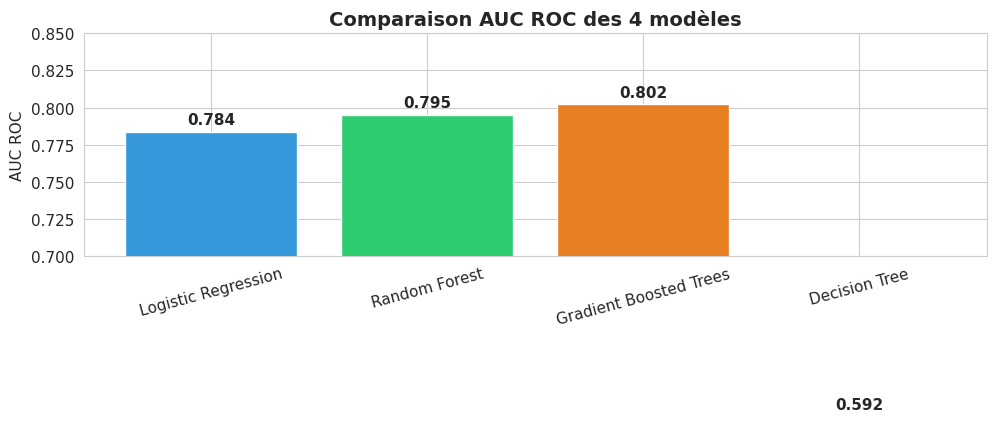


Meilleur modèle : Gradient Boosted Trees


In [84]:
# Bar chart comparant les 4 modèles sur l'AUC ROC

plt.figure(figsize=(10, 6))


bars = plt.bar(

    results["Modèle"],

    results["AUC ROC"],

    color=["#3498db", "#2ecc71", "#e67e22", "#9b59b6"]
)


# Ajouter la valeur au-dessus de chaque barre
for bar in bars:

    height = bar.get_height()

    plt.text(

        bar.get_x() + bar.get_width() / 2,

        height + 0.005,

        f"{height:.3f}",

        ha="center",

        fontweight="bold"
    )


plt.title("Comparaison AUC ROC des 4 modèles", fontsize=14, fontweight="bold")

plt.ylabel("AUC ROC")

plt.ylim(0.7, 0.85)

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()


print(f"\nMeilleur modèle : {best_model_name}")


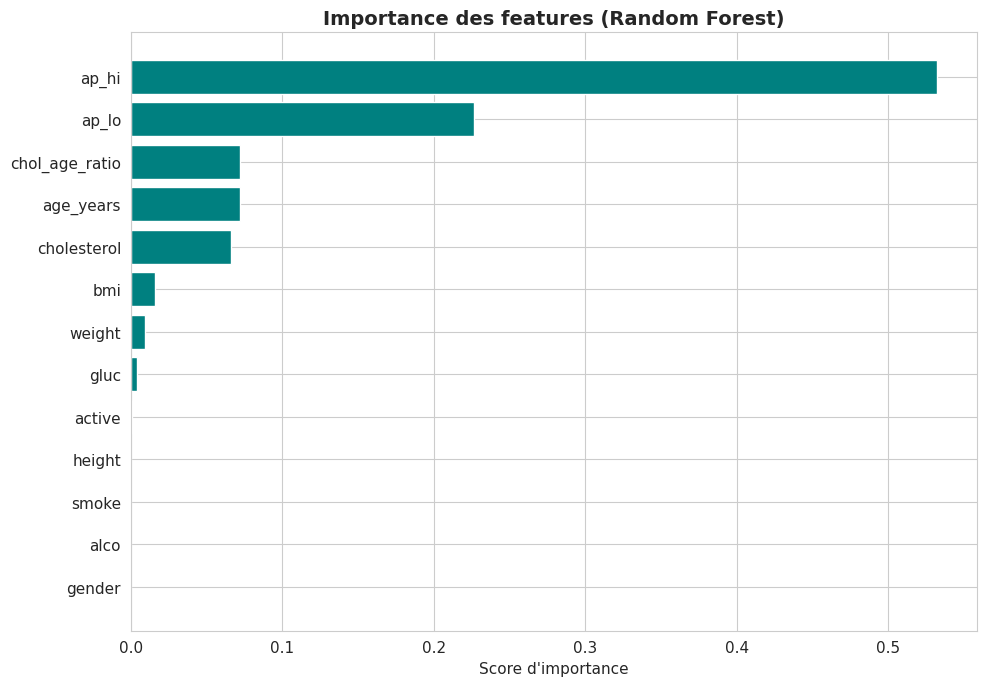


=== Top 3 features les plus importantes ===
       Feature  Importance
         ap_hi    0.531806
         ap_lo    0.226542
chol_age_ratio    0.072194


In [85]:
# Bar chart horizontal de l'importance des features

plt.figure(figsize=(10, 7))


# Trier par importance croissante pour bar chart horizontal
df_imp_sorted = df_importance.sort_values("Importance", ascending=True)


plt.barh(

    df_imp_sorted["Feature"],

    df_imp_sorted["Importance"],

    color="teal"
)

plt.title("Importance des features (Random Forest)", fontsize=14, fontweight="bold")

plt.xlabel("Score d'importance")

plt.tight_layout()

plt.show()


# Top 3
print("\n=== Top 3 features les plus importantes ===")

print(df_importance.head(3).to_string(index=False))


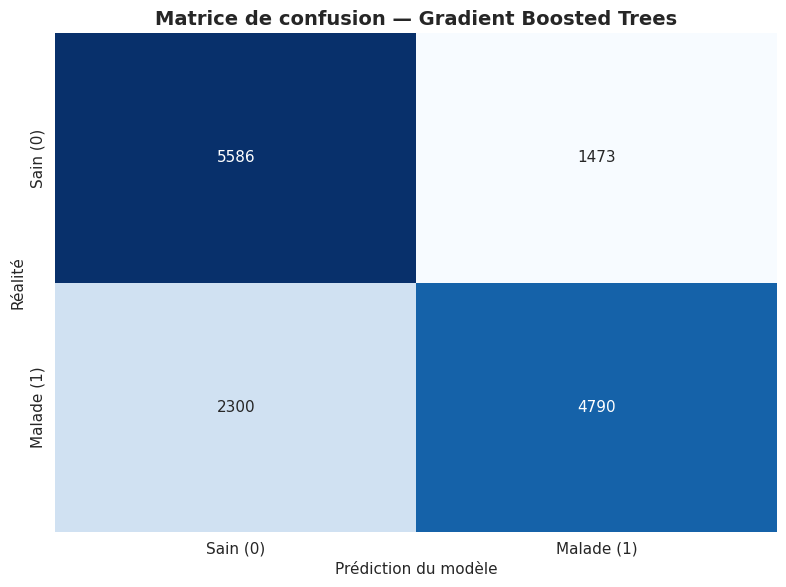


Vrais Négatifs (sains bien classés)   : 5586
Faux Positifs (sains classés malades)  : 1473
Faux Négatifs (malades classés sains)  : 2300
Vrais Positifs (malades bien classés)  : 4790


In [86]:
# Sélectionner les prédictions du meilleur modèle

if best_model_name == "Logistic Regression":
    best_predictions = lr_predictions
elif best_model_name == "Random Forest":
    best_predictions = rf_predictions
elif best_model_name == "Gradient Boosted Trees":
    best_predictions = gbt_predictions
else:
    best_predictions = dt_predictions


# Convertir en pandas (juste les 2 colonnes nécessaires)
pred_pd = best_predictions.select(

    "cardio",

    "prediction"

).toPandas()


# Calculer la matrice de confusion
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(

    pred_pd["cardio"],

    pred_pd["prediction"]
)


# Afficher avec seaborn heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=["Sain (0)", "Malade (1)"],

    yticklabels=["Sain (0)", "Malade (1)"],

    cbar=False
)

plt.title(f"Matrice de confusion — {best_model_name}", fontsize=14, fontweight="bold")

plt.xlabel("Prédiction du modèle")

plt.ylabel("Réalité")

plt.tight_layout()

plt.show()


# Calcul détaillé
tn, fp, fn, tp = cm.ravel()

print(f"\nVrais Négatifs (sains bien classés)   : {tn}")

print(f"Faux Positifs (sains classés malades)  : {fp}")

print(f"Faux Négatifs (malades classés sains)  : {fn}")

print(f"Vrais Positifs (malades bien classés)  : {tp}")


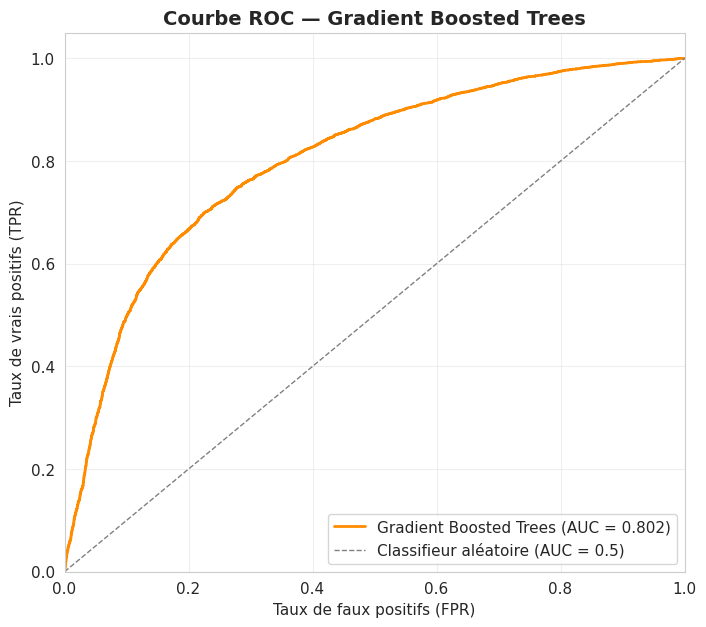


AUC ROC du modèle : 0.8021


In [87]:
# Pour la courbe ROC, on a besoin des probabilités

from pyspark.ml.functions import vector_to_array

from pyspark.sql.functions import col as spark_col


# Extraire la probabilité de la classe 1 (malade)
# probability est un Vector, on prend l'élément à l'index 1
proba_df = best_predictions.withColumn(

    "proba_array",

    vector_to_array(spark_col("probability"))

).select(

    "cardio",

    spark_col("proba_array")[1].alias("proba_malade")

).toPandas()


# Calculer la courbe ROC avec sklearn
from sklearn.metrics import roc_curve, auc as sk_auc


fpr, tpr, _ = roc_curve(

    proba_df["cardio"],

    proba_df["proba_malade"]
)


roc_auc = sk_auc(fpr, tpr)


# Tracer la courbe
plt.figure(figsize=(8, 7))

plt.plot(

    fpr,

    tpr,

    color="darkorange",

    lw=2,

    label=f"{best_model_name} (AUC = {roc_auc:.3f})"
)

plt.plot(

    [0, 1],

    [0, 1],

    color="gray",

    lw=1,

    linestyle="--",

    label="Classifieur aléatoire (AUC = 0.5)"
)

plt.xlim([0.0, 1.0])

plt.ylim([0.0, 1.05])

plt.xlabel("Taux de faux positifs (FPR)")

plt.ylabel("Taux de vrais positifs (TPR)")

plt.title(f"Courbe ROC — {best_model_name}", fontsize=14, fontweight="bold")

plt.legend(loc="lower right")

plt.grid(True, alpha=0.3)

plt.show()


print(f"\nAUC ROC du modèle : {roc_auc:.4f}")


In [88]:
# Rapport synthétique final

print("=" * 60)

print("RAPPORT FINAL DU PROJET BIG DATA")

print("Prédiction des Maladies Cardiovasculaires")

print("=" * 60)


print("\n--- DATASET ---")

print(f"Source        : Cardiovascular Disease Dataset (Kaggle)")

print(f"Nombre lignes : {df.count():,}")

print(f"Colonnes      : {len(df.columns)}")

print(f"Valeurs manquantes : 0")

print(f"Doublons      : 0")


print("\n--- PIPELINE BIG DATA ---")

print("1. Acquisition  : PySpark + simulation Kafka")

print("2. Stockage     : Google Drive (substitut HDFS)")

print("3. Prétraitement: Spark ML Pipeline (VectorAssembler + StandardScaler)")

print("4. Analyse      : Spark MLlib (4 modèles)")

print("5. Visualisation: matplotlib + seaborn + Spark SQL (équivalent Hive)")


print("\n--- MODÈLES TESTÉS ---")

print(results.round(4).to_string(index=False))


print("\n--- MEILLEUR MODÈLE ---")

print(f"Nom     : {best_model_name}")

print(f"AUC ROC : {best_auc:.4f}")

print(f"Sauvegardé sur Google Drive")


print("\n--- TOP 3 FACTEURS DE RISQUE ---")

print(df_importance.head(3).to_string(index=False))


print("\n" + "=" * 60)

print("PROJET TERMINÉ — Tous les livrables sont prêts")

print("=" * 60)


RAPPORT FINAL DU PROJET BIG DATA
Prédiction des Maladies Cardiovasculaires

--- DATASET ---
Source        : Cardiovascular Disease Dataset (Kaggle)
Nombre lignes : 70,000
Colonnes      : 17
Valeurs manquantes : 0
Doublons      : 0

--- PIPELINE BIG DATA ---
1. Acquisition  : PySpark + simulation Kafka
2. Stockage     : Google Drive (substitut HDFS)
3. Prétraitement: Spark ML Pipeline (VectorAssembler + StandardScaler)
4. Analyse      : Spark MLlib (4 modèles)
5. Visualisation: matplotlib + seaborn + Spark SQL (équivalent Hive)

--- MODÈLES TESTÉS ---
                Modèle  Accuracy  Precision  Recall  F1 Score  AUC ROC
   Logistic Regression    0.7193     0.7206  0.7193    0.7190   0.7837
         Random Forest    0.7248     0.7285  0.7248    0.7237   0.7953
Gradient Boosted Trees    0.7333     0.7366  0.7333    0.7325   0.8021
         Decision Tree    0.7290     0.7388  0.7290    0.7263   0.5921

--- MEILLEUR MODÈLE ---
Nom     : Gradient Boosted Trees
AUC ROC : 0.8021
Sauvegardé su